<a href="https://colab.research.google.com/github/patilyogita7/Artificial_Intelligence_Lab_SE_A_45/blob/master/Practical_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

 Model Performance 
Mean Squared Error: 24.29
R2 Score: 0.67


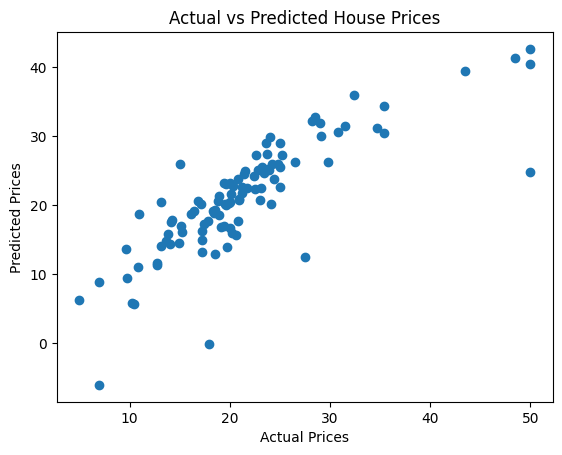

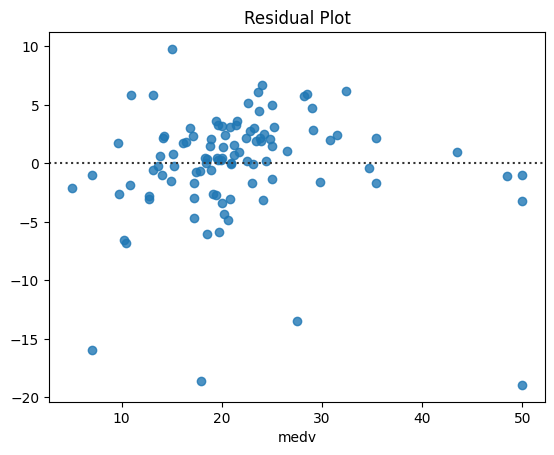

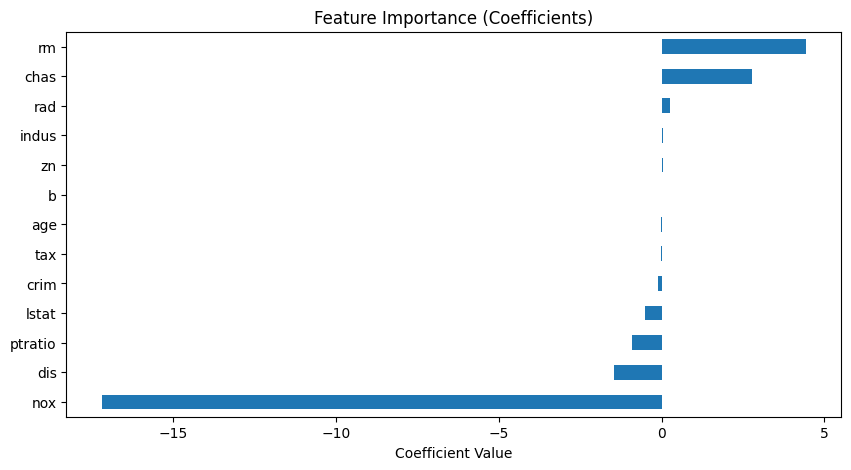

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print("First 5 Rows:")
print(df.head())

# 2. Data Preprocessing

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

X = df.drop(columns=['medv'])   # Features
y = df['medv']                  # Target (house price)

# 3. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions

y_pred = model.predict(X_test)

# 6. Model Evaluation

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Model Performance ")
print("Mean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 2))

# 7. Visualization

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual Plot
plt.figure()
sns.residplot(x=y_test, y=y_pred)
plt.title("Residual Plot")
plt.show()

# Feature Importance (coefficients)
plt.figure(figsize=(10,5))
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()